In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np, matplotlib.pyplot as plt
from jax import random

from Style     import useAA         
from Tensorize import loadDataset
from NSF       import makeModels, train, checkTransition
from GapFill   import fillGaps, drwGPBaseline, gapWidths, coverage, plotGapFill, evalCurve

useAA()
DATA = "/Users/anacecilialr/GitHub/MASS/MASS-Thesis/data/VaryTau/"

## 1. Load

`loadDataset` normalizes: $t \to t/t_{max}$, $y \to y/\sigma$.

Note the validation set is loaded with the **training** scales. Letting it compute its own would leak validation statistics into the model's input distribution.

In [2]:
D = loadDataset(f"{DATA}/train.npz")
V = loadDataset(f"{DATA}/val.npz", t_scale=D["t_scale"], y_scale=D["y_scale"])   # SAME scales

# all the curves no longer share the same tau and sigma
tau_n_all = np.asarray(D["tau"])
print(f"train {D['t'].shape}   val {V['t'].shape}")
print(f"tau_n: {tau_n_all.min():.3f}-{tau_n_all.max():.3f} across curves "
      f"(median {np.median(tau_n_all):.3f})")
# prints sigma normalized
print(f"sigma_n = {float(D['sigma'][0]):.2f},  max|y| = {float(abs(D['y'][D['mask']]).max()):.2f},  max t = {float(D['t'].max()):.2f}")

train (2400, 108)   val (600, 101)
tau_n: 0.062-0.405 across curves (median 0.152)
sigma_n = 1.00,  max|y| = 5.18,  max t = 1.00


## 2. Train

Total loss (Kiyohara Eq. 11):
$$\mathcal{L}(\theta,\xi) = \underbrace{-\mathbb{E}_{\mathcal{D}}\left[\log p_\theta(x_{t_j}\mid x_{t_i})\right]}_{\mathcal{L}_{\rm NLL}} + \lambda\,\mathcal{L}_{\rm flow}(\theta,\xi)$$

Without **$\mathcal{L}_{\rm NLL}$** the model is trained only to be *self-consistent*, a property infinitely many wrong dynamics satisfy, and it never learns the DRW at all. Gap filling would still look plausible, because the bridge is conditioned on real endpoints at inference

`lam = 0.1`: Kiyohara use 0.4 (Lorenz), find ~0.03 best (mocap), and report that
sub-order-of-magnitude values suffice.

  step   100 | loss   1.5381
  step   200 | loss   1.0838
  step   300 | loss   1.0718
  step   400 | loss   1.0733
  step   500 | loss   1.0651
  step   600 | loss   1.0593

final loss 1.070   <- ~1-2 is healthy; ~50 means unnormalised data


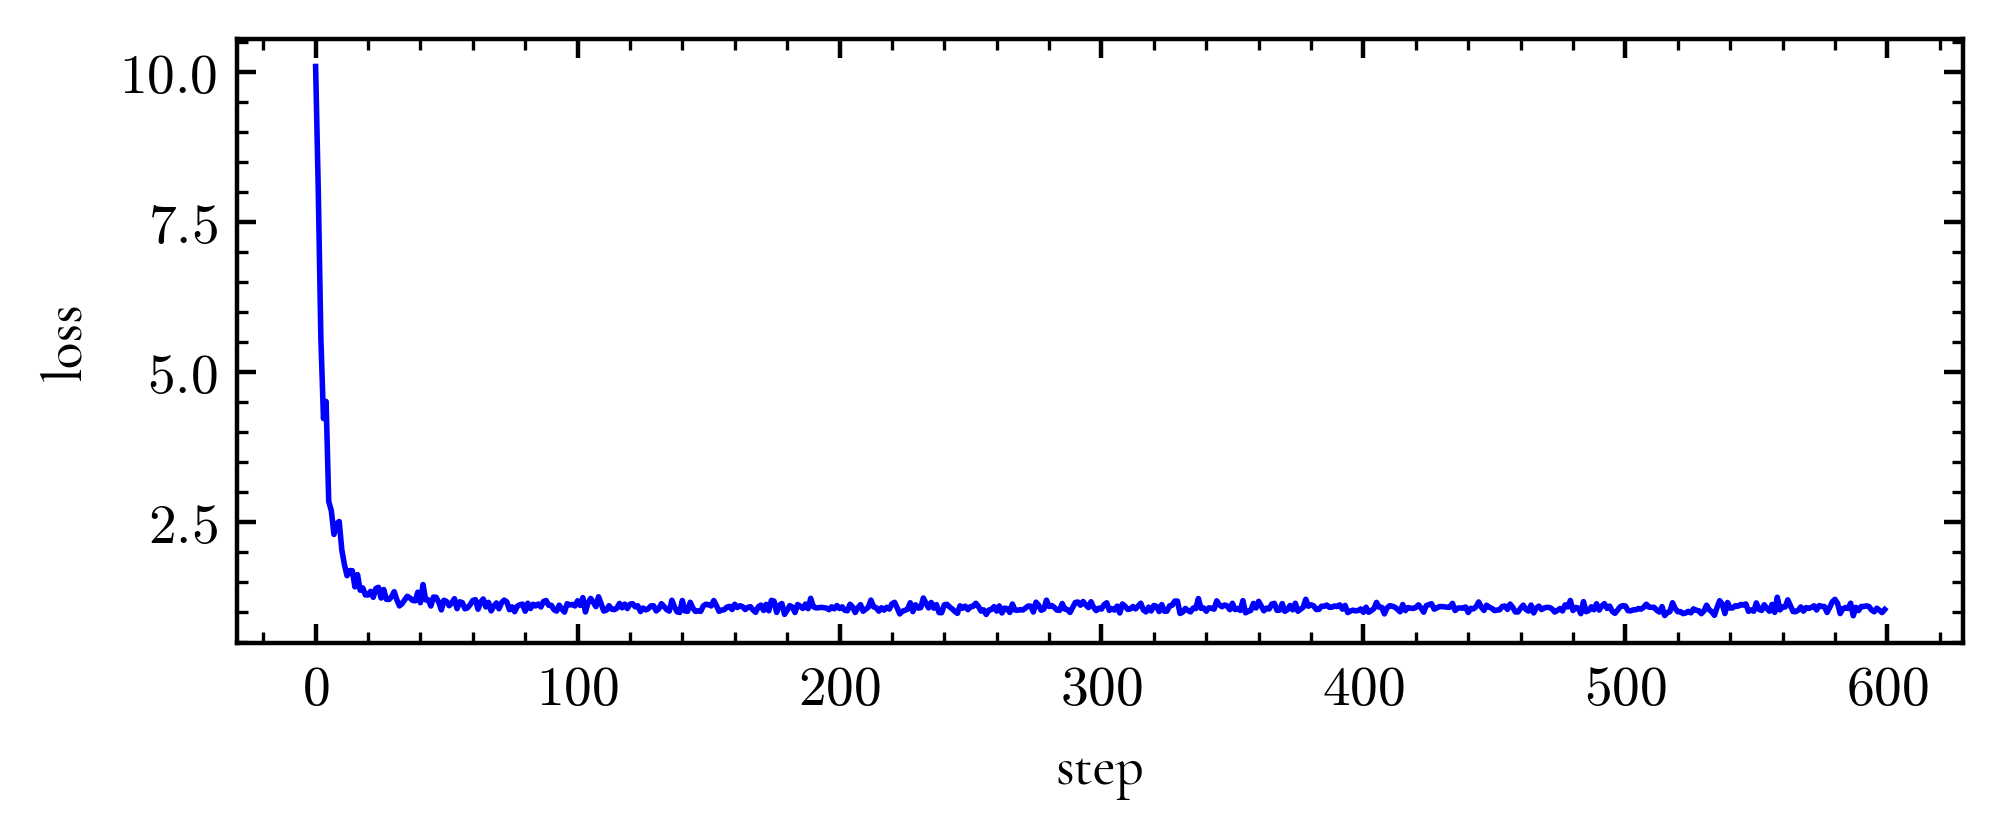

In [3]:
flow, bridge = makeModels(random.PRNGKey(0))
(flow, bridge), hist = train(flow, bridge, D, random.PRNGKey(1),
                             steps=600, batch=16, lr=2e-3, lam=0.1, n_trip=32)

print(f"\nfinal loss {np.mean(hist[-50:]):.3f}   <- ~1-2 is healthy; ~50 means unnormalised data")
plt.figure(figsize=(5, 2.2))
plt.plot(hist, lw=1, color="blue")
plt.xlabel("step"); plt.ylabel("loss")
plt.tight_layout()
plt.savefig("/Users/anacecilialr/GitHub/MASS/MASS-Thesis/assets/5_figures/VaryTauExp/Loss.pdf")
#plt.savefig("/Users/anacecilialr/GitHub/MASS/MASS-Thesis/assets/5_figures/FixedTauExp/Loss.pdf")
plt.show()

## 3. Validation

The true transition in closed form:

$$X_t \mid X_s \;\sim\; \mathcal{N}\!\left(e^{-\Delta t/\tau}X_s,\;\; \sigma^2\left(1-e^{-2\Delta t/\tau}\right)\right)$$

so the learned $p_\theta(x_t\mid x_s,\Delta t)$ can be checked against it **directly**. Kiyohara could
not do this on Lorenz or mocap. Important plot to add

Run it before. **Mean must decay to 0; sd must saturate at $\sigma$.**
If either grows without bound, stop, the usual cause is unnormalized data.

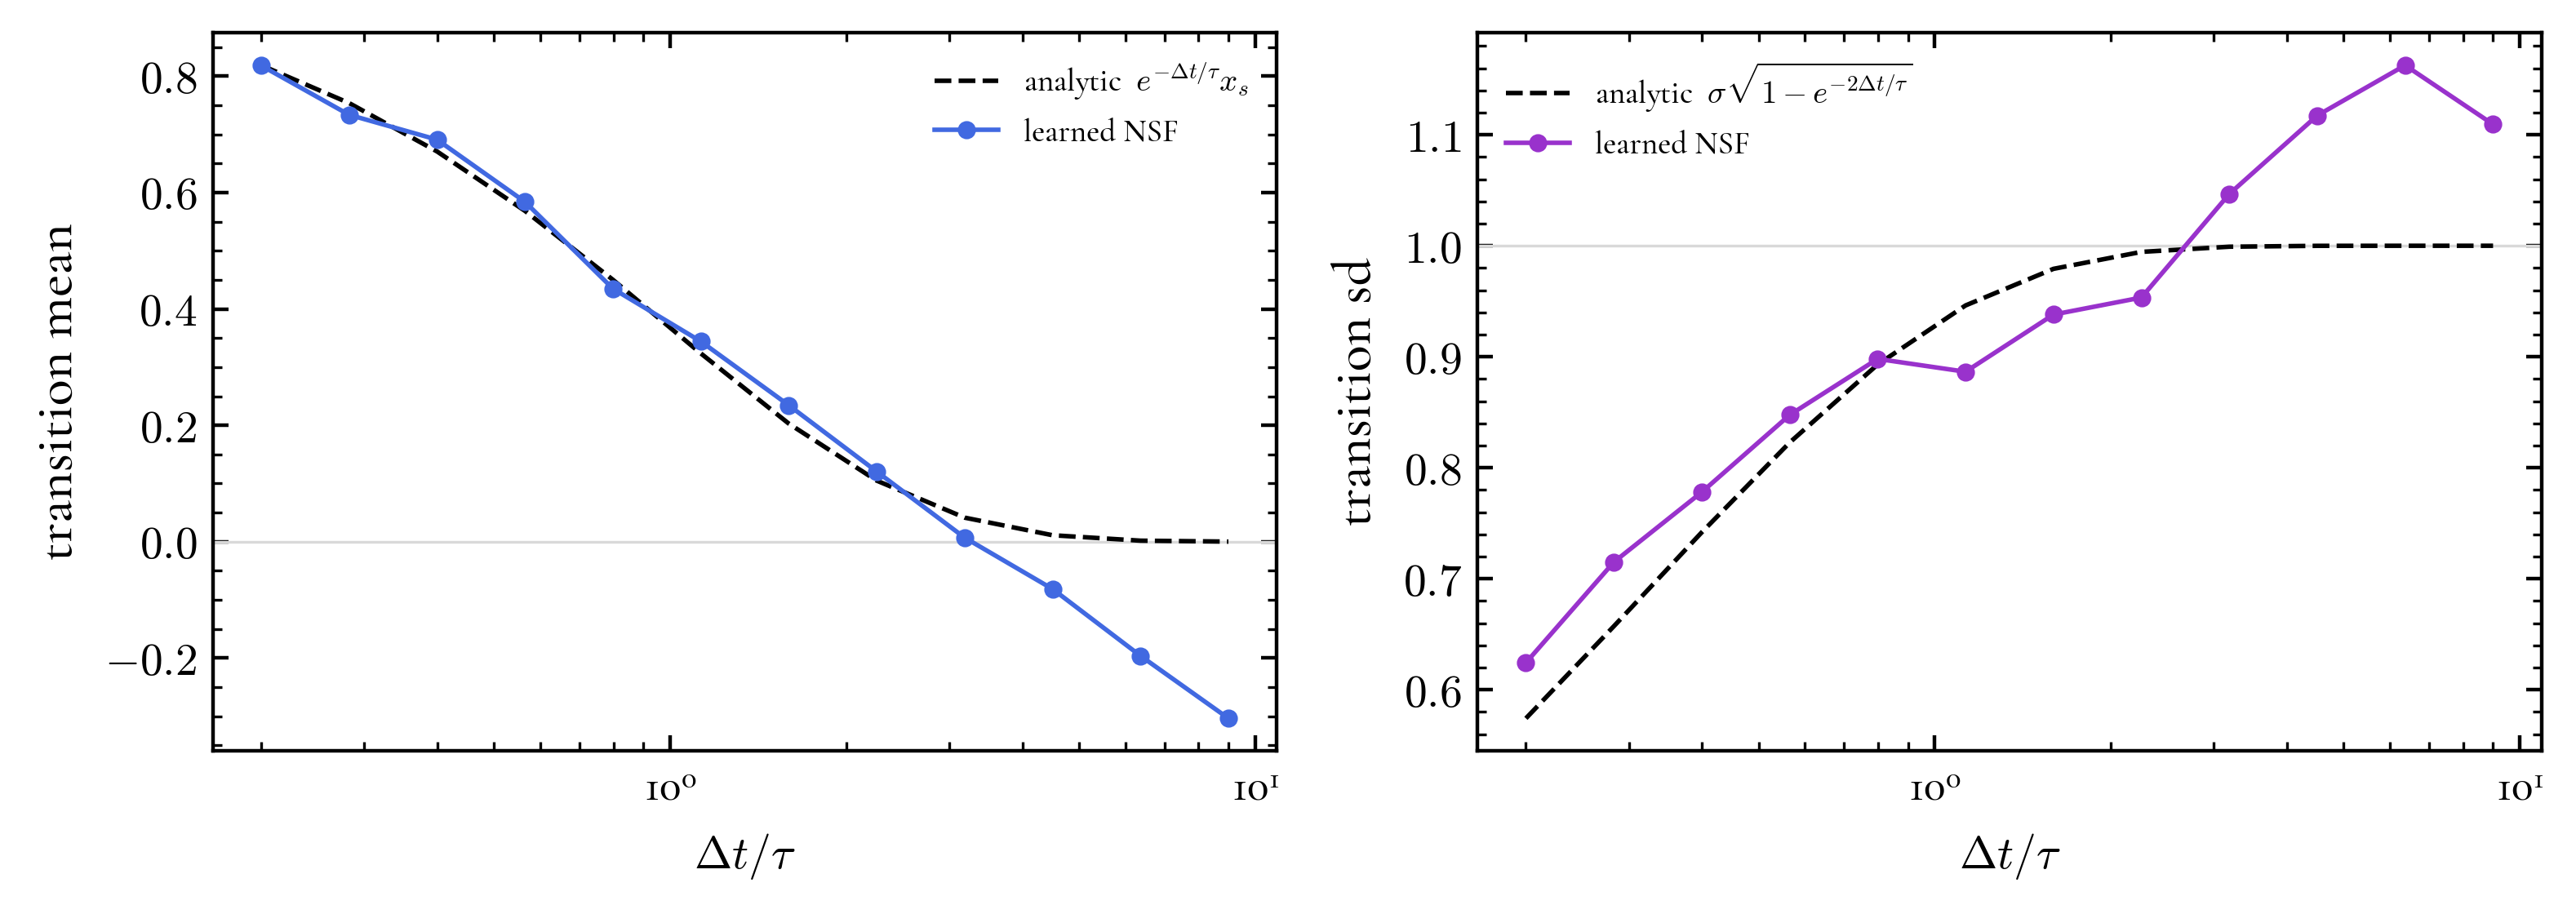

  mean @ 9 tau : -0.30  (analytic +0.00)   -> must decay to 0
  sd   @ 9 tau : 1.11  (analytic 1.00)   -> must saturate at 1


In [4]:
# for fixed tau
# dts = np.logspace(np.log10(0.2*tau_n), np.log10(9*tau_n), 12)
# lm, lv, tm, tv = checkTransition(flow, tau_n, sig_n, 1.0, dts, random.PRNGKey(2), n=4000)
i_ref = int(np.argmin(np.abs(np.asarray(D["tau"]) - np.median(D["tau"]))))
tau_ref, sig_ref = float(D["tau"][i_ref]), float(D["sigma"][i_ref])
dts = np.logspace(np.log10(0.2*tau_ref), np.log10(9*tau_ref), 12)
lm, lv, tm, tv = checkTransition(flow, tau_ref, sig_ref, 1.0, dts, random.PRNGKey(2), n=4000)

fig, ax = plt.subplots(1, 2, figsize=(8, 2.9))
ax[0].axhline(0, color="0.85", lw=.6)
ax[0].plot(dts/tau_ref, tm, "k--", label=r"analytic  $e^{-\Delta t/\tau}x_s$")
ax[0].plot(dts/tau_ref, lm, "o-", ms=3, color="royalblue", label="learned NSF")
ax[0].set_ylabel("transition mean", fontsize=12)
ax[1].axhline(sig_ref, color="0.85", lw=.6)
ax[1].plot(dts/tau_ref, np.sqrt(tv), "k--", label=r"analytic  $\sigma\sqrt{1-e^{-2\Delta t/\tau}}$")
ax[1].plot(dts/tau_ref, np.sqrt(lv), "o-", ms=3, color="darkorchid", label="learned NSF")
ax[1].set_ylabel("transition sd", fontsize=12)
for a in ax: 
    a.set_xscale("log")
    a.set_xlabel(r"$\Delta t/\tau$")
    a.legend(fontsize=7)
plt.tight_layout()
plt.savefig("/Users/anacecilialr/GitHub/MASS/MASS-Thesis/assets/5_figures/VaryTauExp/LearnedTransMedian.pdf")
#plt.savefig("/Users/anacecilialr/GitHub/MASS/MASS-Thesis/assets/5_figures/FixedTauExp/LearnedTrans.pdf")
plt.show()

print(f"  mean @ 9 tau : {lm[-1]:+.2f}  (analytic {tm[-1]:+.2f})   -> must decay to 0")
print(f"  sd   @ 9 tau : {np.sqrt(lv[-1]):.2f}  (analytic {np.sqrt(tv[-1]):.2f})   -> must saturate at 1")

## 4. Gap filling, against the Bayes-optimal baseline

The DRW-GP is handed the **true** $\tau$ and $\sigma$, and the data were generated from exactly that
process, making it the optimal filler by construction. 

Filling a gap means conditioning on **both** endpoints, that is what a bridge is. The transition
alone conditions on the left endpoint only, which is forecasting: it drifts and its band widens
monotonically.

In [5]:
i = 10  # a curve the model has never seen
m = np.asarray(V["mask"][i])
t_o, y_o, e_o = np.asarray(V["t"][i])[m], np.asarray(V["y"][i])[m], np.asarray(V["yerr"][i])[m]
t_tr, y_tr = np.asarray(V["t_true"]), np.asarray(V["y_true"][i])
tau_i, sig_i = float(V["tau"][i]), float(V["sigma"][i])   # this curve's params


t_rec, s_rec = fillGaps(bridge, t_o, y_o, n_samples=800, grid_per_gap=12, seed=0)
mu, sd = drwGPBaseline(t_o, y_o, e_o, t_rec, tau_i, sig_i)
print(f"reconstructed on {t_rec.size} points from {t_o.size} observations")

reconstructed on 1171 points from 91 observations


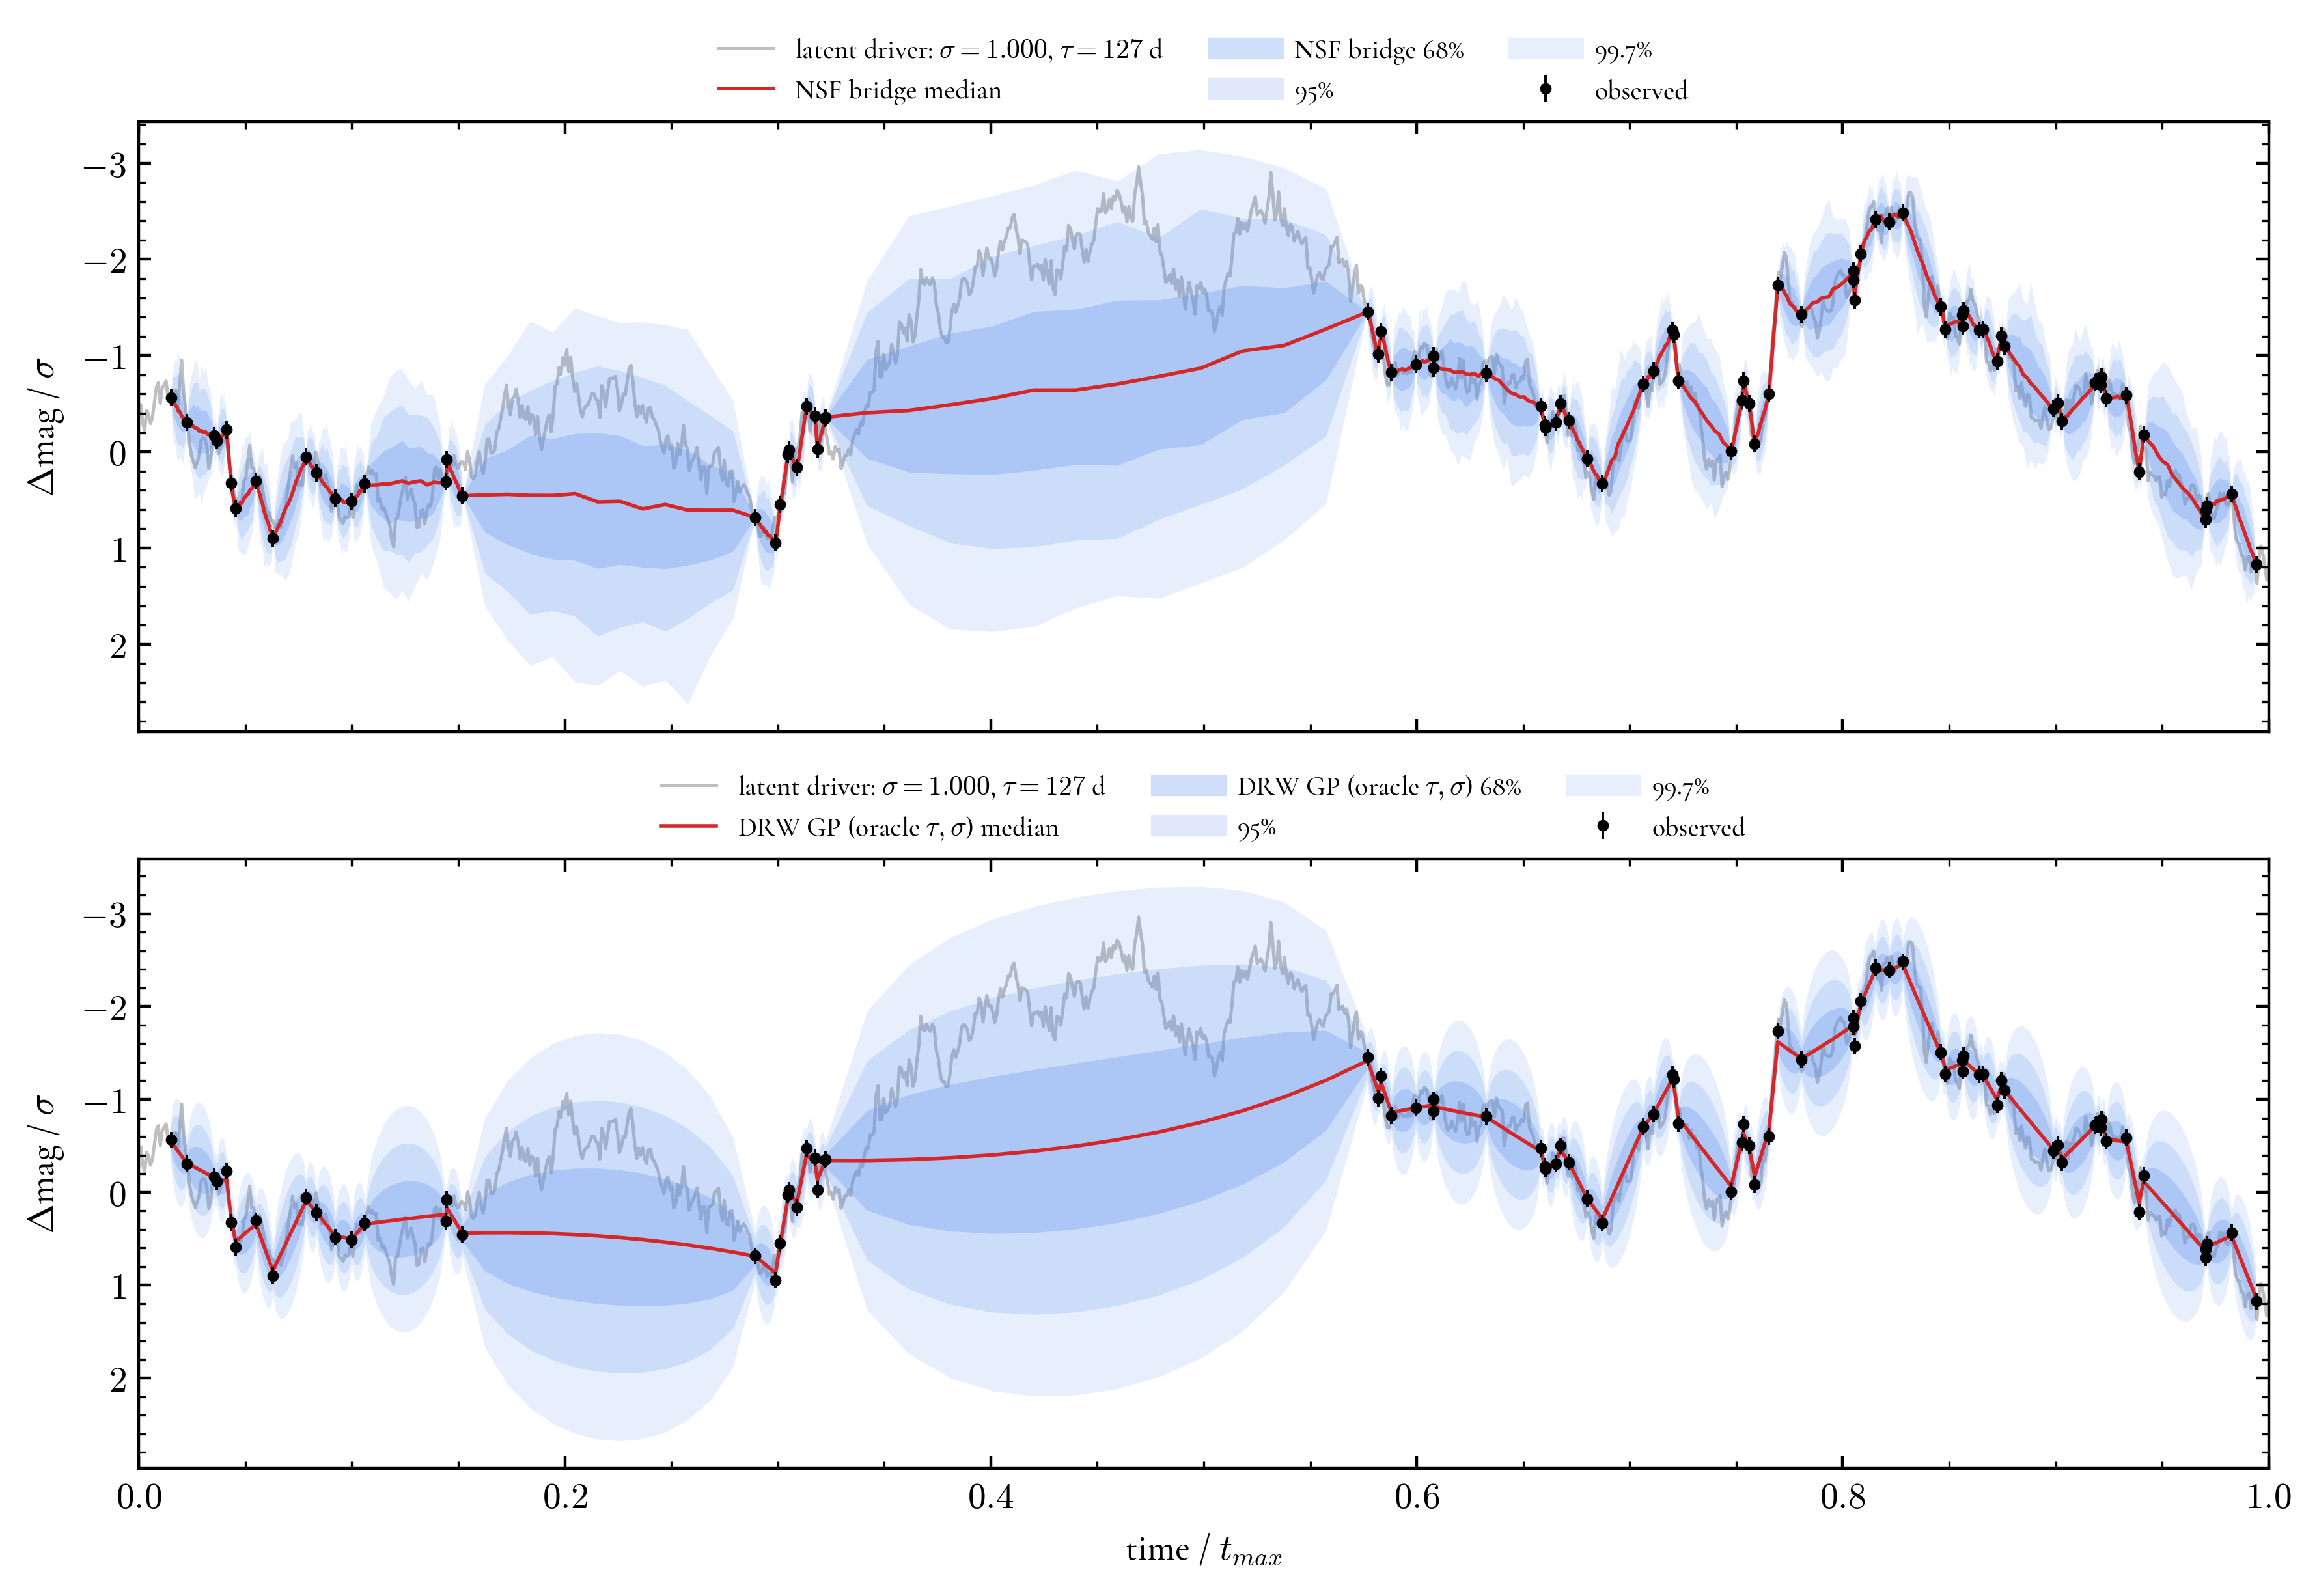

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6.2), sharex=True)
plotGapFill(t_tr, y_tr, t_o, y_o, e_o, t_rec, s_rec, ax=axes[0], label="NSF bridge",
            tau=tau_i, sigma=sig_i, t_scale=D["t_scale"])          
plotGapFill(t_tr, y_tr, t_o, y_o, e_o, t_rec, (mu, sd), ax=axes[1],  
            label=r"DRW GP (oracle $\tau,\sigma$)",
            tau=tau_i, sigma=sig_i, t_scale=D["t_scale"])
axes[0].set_xlabel("")
plt.tight_layout()
plt.savefig("/Users/anacecilialr/GitHub/MASS/MASS-Thesis/assets/5_figures/VaryTauExp/FilledLightCurve.pdf")
#plt.savefig("/Users/anacecilialr/GitHub/MASS/MASS-Thesis/assets/5_figures/FixedTauExp/FilledLightCurve.pdf")
plt.show()

In [7]:
res = [evalCurve(bridge, D, V, i, n_samples=200, grid_per_gap=12, seed=i)
       for i in range(V["t"].shape[0])]          # all val curves (drop to range(40) to go faster)

print(f"{'':16s}{'coverage@68% (med,16-84)':>28s}{'RMSE (med,16-84)':>24s}")
for lab, ck, rk in [("NSF bridge", "nsf_cov", "nsf_rmse"),
                    ("DRW-GP oracle", "gp_cov", "gp_rmse")]:
    cov = np.array([x[ck] for x in res]); rms = np.array([x[rk] for x in res])
    print(f"{lab:16s}  {np.median(cov):.2f} [{np.percentile(cov,16):.2f}, {np.percentile(cov,84):.2f}]"
          f"      {np.median(rms):.3f} [{np.percentile(rms,16):.3f}, {np.percentile(rms,84):.3f}]")

dr = np.array([x["nsf_rmse"] - x["gp_rmse"] for x in res])
print(f"\nNSF is {100*np.median(dr)/np.median([x['gp_rmse'] for x in res]):.0f}% above Bayes-optimal (median)")

                    coverage@68% (med,16-84)        RMSE (med,16-84)
NSF bridge        0.61 [0.55, 0.67]      0.172 [0.151, 0.204]
DRW-GP oracle     0.70 [0.66, 0.73]      0.167 [0.144, 0.200]

NSF is 3% above Bayes-optimal (median)


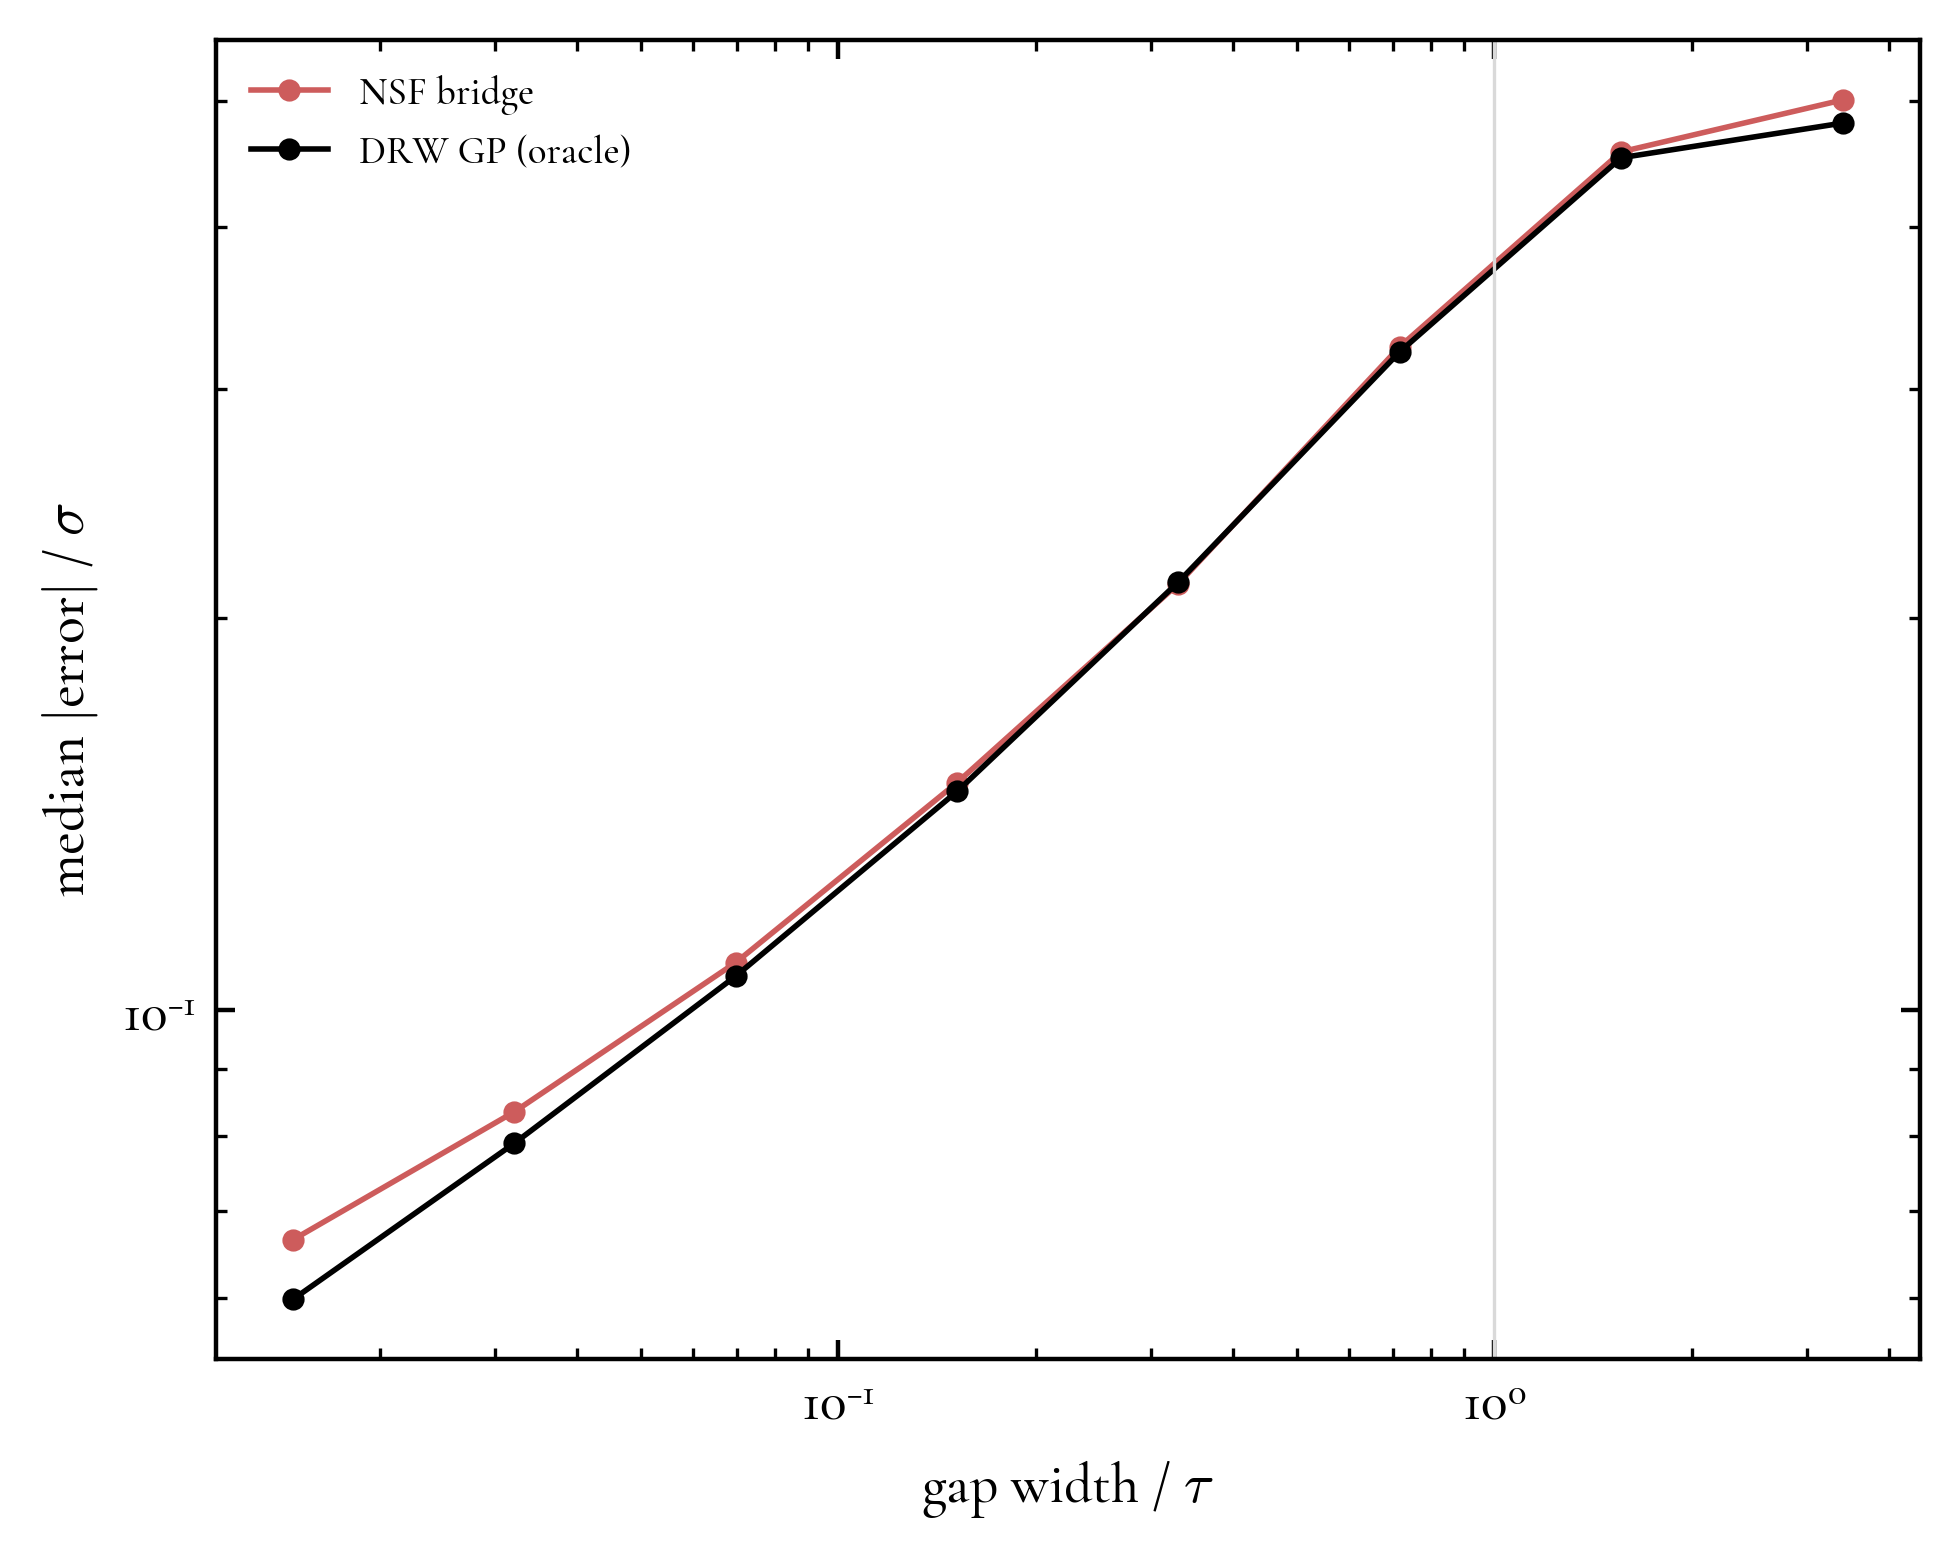

In [8]:
# interior so only gap points enter and not observations, masked BEFORE pooling
w   = np.concatenate([x["gap_tau"][x["interior"]] for x in res])
enf = np.concatenate([np.abs(np.median(x["s_rec"],0) - x["y_ref"])[x["interior"]] for x in res])
egp = np.concatenate([np.abs(x["mu"] - x["y_ref"])[x["interior"]] for x in res])

bins = np.logspace(-2, 0.7, 9); cen = np.sqrt(bins[:-1]*bins[1:])
idx = np.digitize(w, bins) - 1
plt.figure(figsize=(5, 4))
for lab, e, col in [("NSF bridge", enf, "indianred"), ("DRW GP (oracle)", egp, "k")]:
    med = [np.median(e[idx == b]) if (idx == b).sum() > 20 else np.nan for b in range(len(cen))]
    plt.plot(cen, med, "o-", ms=3, color=col, label=lab)
plt.xscale("log"); plt.yscale("log"); plt.axvline(1.0, color="0.85", lw=.6)
plt.xlabel(r"gap width / $\tau$"); plt.ylabel(r"median $|$error$|$ / $\sigma$")
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig("/Users/anacecilialr/GitHub/MASS/MASS-Thesis/assets/5_figures/VaryTauExp/Error.pdf")
#plt.savefig("/Users/anacecilialr/GitHub/MASS/MASS-Thesis/assets/5_figures/FixedTauExp/Error.pdf")
plt.show()

In [9]:
tau = np.array([float(V["tau"][i]) for i in range(len(res))])
med = np.median(tau)
for name, mask in [("low tau", tau<med), ("high tau", tau>=med)]:
    c = np.array([res[i]["nsf_cov"] for i in np.where(mask)[0]])
    print(f"{name}: coverage {np.median(c):.2f}")

low tau: coverage 0.57
high tau: coverage 0.64


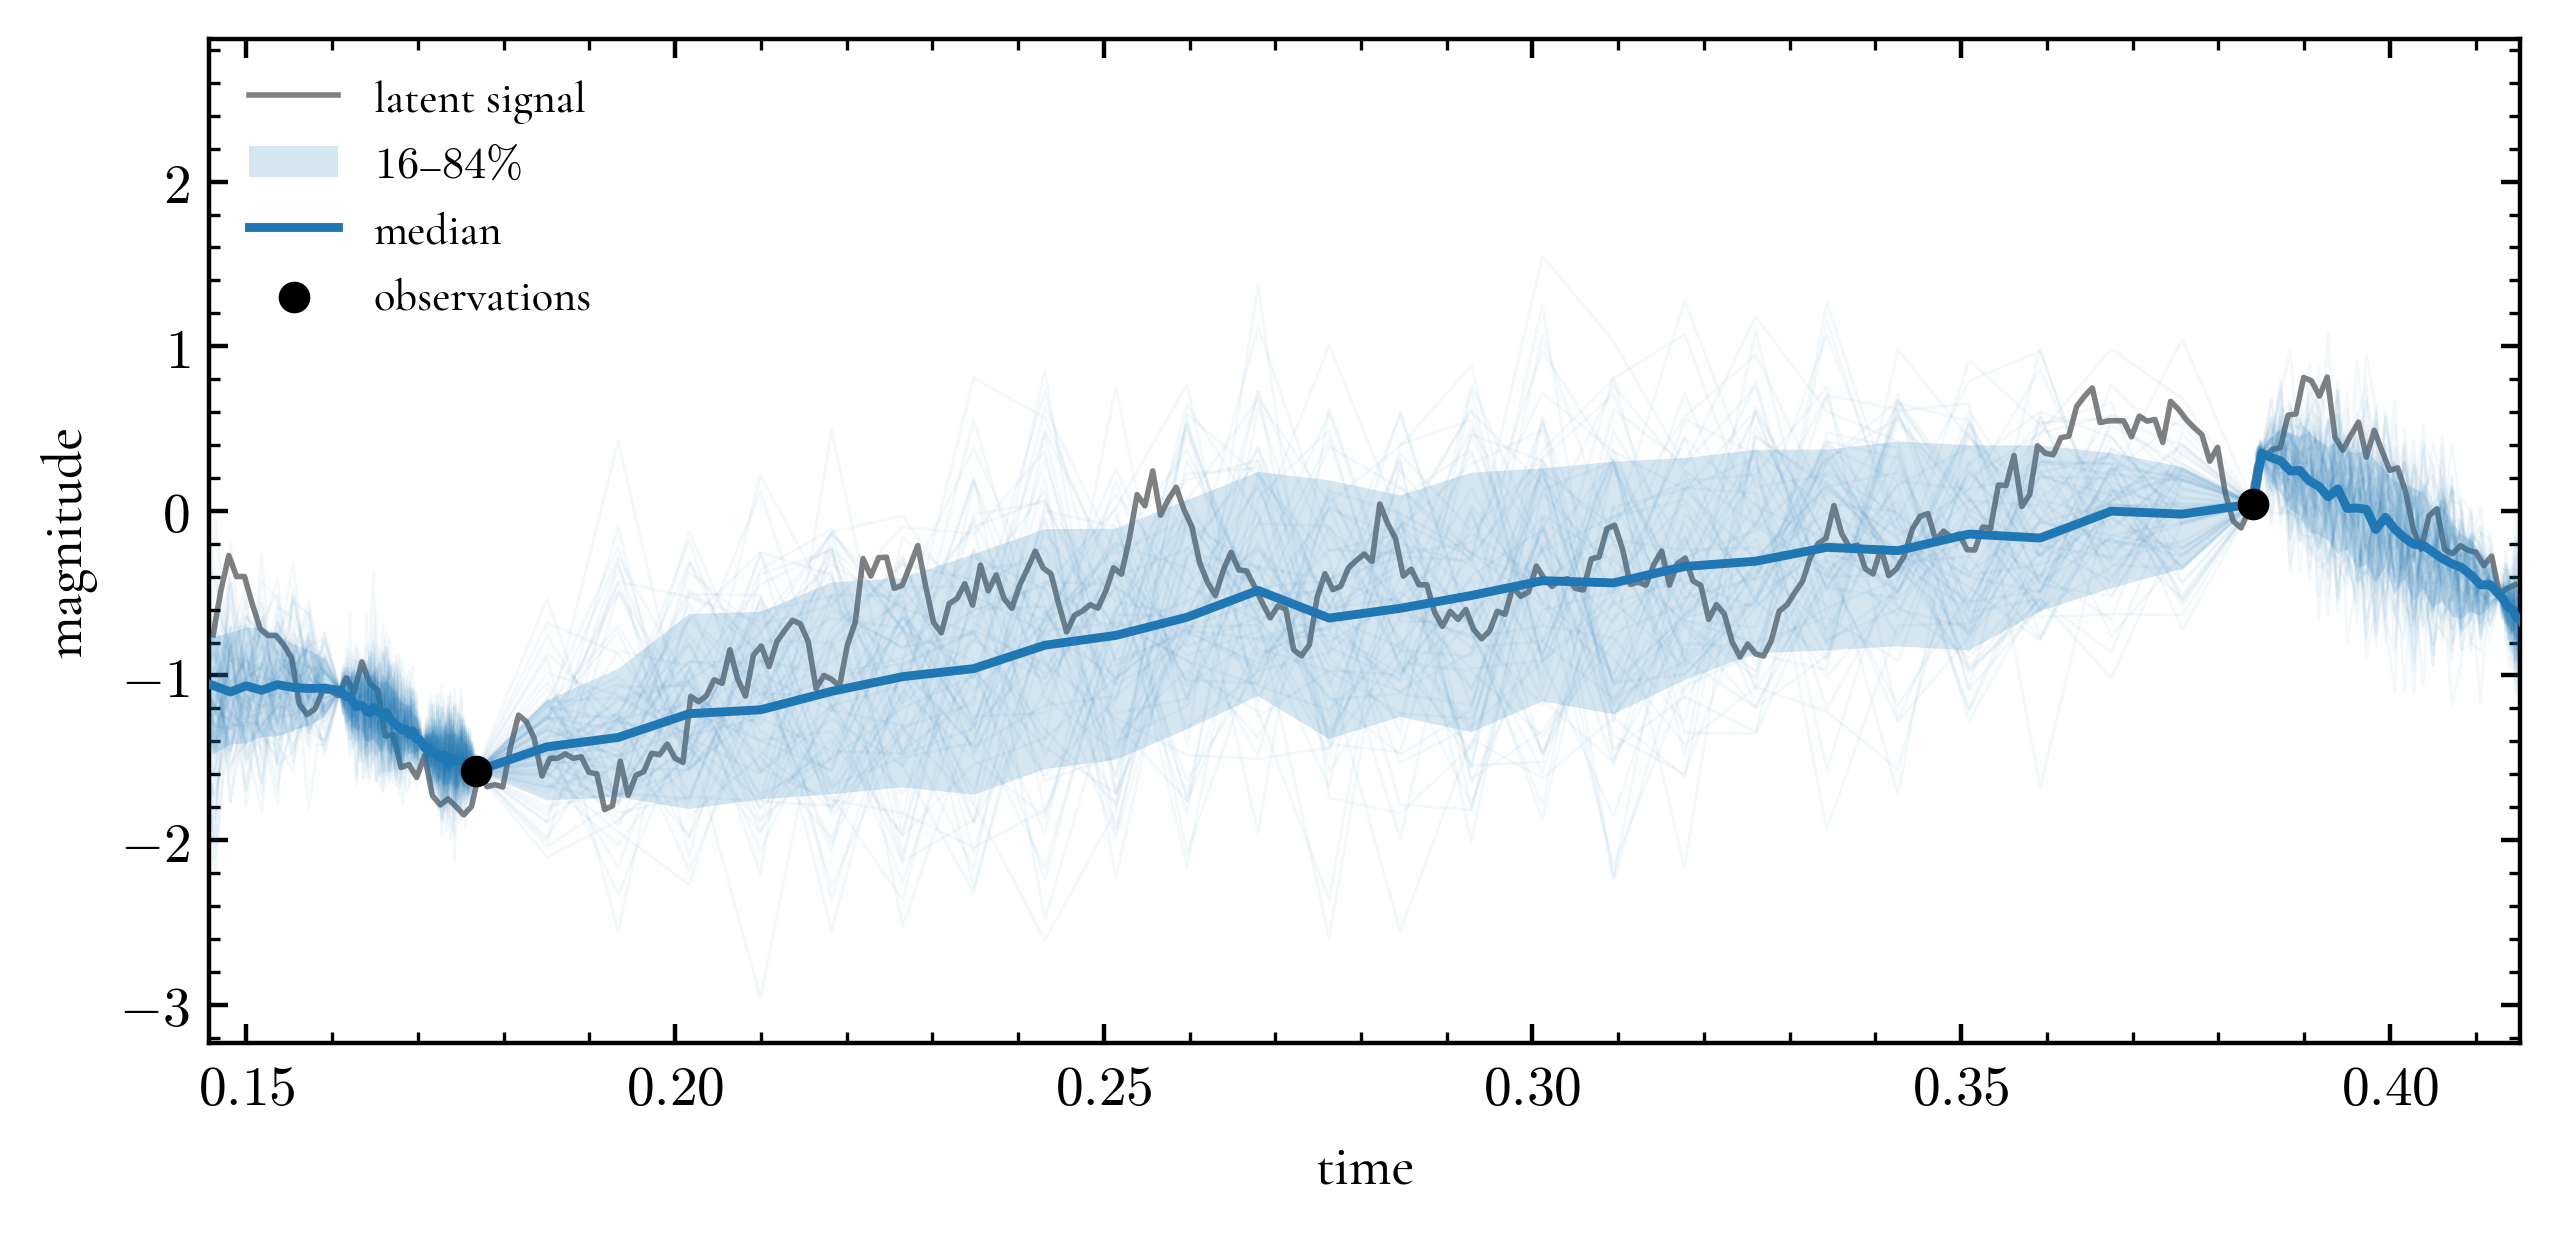

In [ ]:
# MC bridge samples across one gap 
i = 13                                  

m  = np.asarray(V["mask"][i], bool)
t  = np.asarray(V["t"][i])[m]              # normalized obs times
y  = np.asarray(V["y"][i])[m]             # normalized obs values
tt = np.asarray(V["t_true"])              # dense true grid (normalized)
yt = np.asarray(V["y_true"][i])           # dense latent signal

# reconstruct and zoom on the widest inter-observation gap
t_rec, s_rec = fillGaps(bridge, t, y, n_samples=200, grid_per_gap=24, seed=0)
gi     = int(np.argmax(np.diff(t)))
ta, tb = float(t[gi]), float(t[gi+1])
pad    = 0.15 * (tb - ta)
lo_x, hi_x = ta - pad, tb + pad

med = np.median(s_rec, 0)
p16 = np.percentile(s_rec, 16, 0)
p84 = np.percentile(s_rec, 84, 0)

fig, ax = plt.subplots(figsize=(6.5, 3.2))

mt = (tt >= lo_x) & (tt <= hi_x)
ax.plot(tt[mt], yt[mt], color="0.5", lw=1.0, zorder=1, label="latent signal")

for s in s_rec[::3]:                        # individual MC samples
    ax.plot(t_rec, s, color="tab:blue", alpha=0.05, lw=0.5, zorder=2)

ax.fill_between(t_rec, p16, p84, color="tab:blue", alpha=0.18, lw=0, zorder=3,
                label=r"$16$–$84\%$")
ax.plot(t_rec, med, color="tab:blue", lw=1.6, zorder=4, label="median")
ax.scatter([ta, tb], [y[gi], y[gi+1]], color="k", s=22, zorder=5, label="observations")

ax.set_xlim(lo_x, hi_x)
ax.set_xlabel("time")
ax.set_ylabel("magnitude")
ax.legend(fontsize=8, loc="best")
fig.tight_layout()
fig.savefig("/Users/anacecilialr/GitHub/MASS/MASS-Thesis/assets/5_figures/VaryTauExp/MCSamples.pdf")
plt.show()